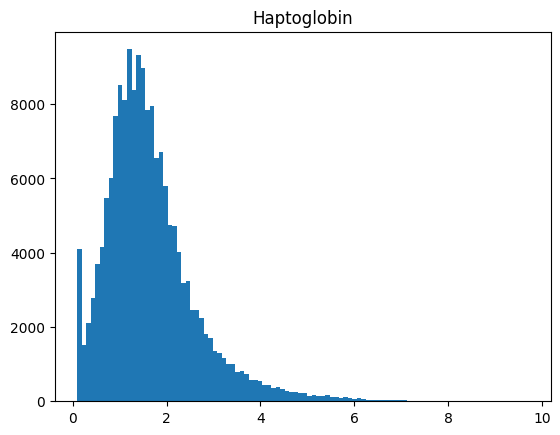

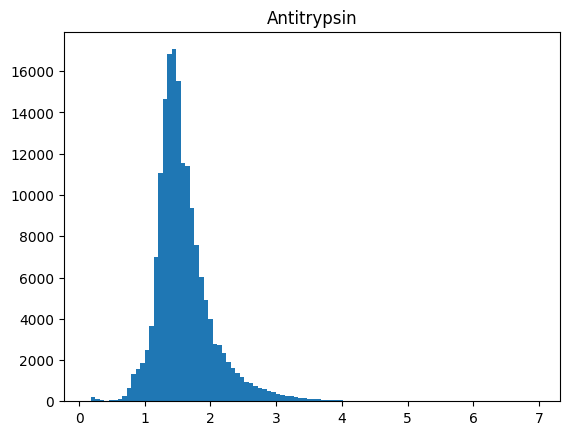

1.5
1.5
0.93


In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from functions.analyte import ANALYTES



con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT id,
                    any_value(pid) as pid, 
                    any_value(value) as value,
                    list(c.comment_nr) as comment_nr,
                    any_value(sign) as sign,
                    any_value(age) as age,
                    any_value(set) as set,
                    any_value(haptoglobin) as haptoglobin,
                    any_value(albumin) as albumin,
                    any_value(orosomukoid) as orosomukoid,
                    any_value(crp) as crp,
                    any_value(antitrypsin) as antitrypsin,
                    any_value(label) as label
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                GROUP BY id
                 """).df()

con.close()

def to_severity(comments: list[int]):
    max_found = 0
    for comment in comments:
        result = map_severity(comment)
        if result > max_found:
            max_found = result
    return max_found
        

def map_severity(label: int) -> int:        
    severity = 0
    match label:
        case 40 |41 |42:
            severity = 1 #absolut 
        case 43 | 44 | 45:
            severity = 2 #relativ
        case _:
            severity = 0
    return severity

protein_cols = [a.col for a in ANALYTES[0:5]]

df = df.dropna(subset=protein_cols)


df['severity'] = df['comment_nr'].apply(to_severity)
df['relativ'] = (df['severity'] == 2).astype(int)
df = df[df['age']> 13]

plt.figure()
plt.title("Haptoglobin")
plt.hist(df['haptoglobin'],bins=100)
plt.show()

plt.figure()
plt.title("Antitrypsin")
plt.hist(df['antitrypsin'],bins=100)
plt.show()

print(np.median(df[df['label'] == 0]['antitrypsin']))
print(np.median(df[df['label'] == 0]['haptoglobin']))
print(np.median(df[df['label'] == 0]['orosomukoid']))



In [2]:
severity_range = [0,1,2]

most_frequent = 0
position_weights = []

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    print(f"Antal fall med klass {i}:{no_occurences}")
    if no_occurences > most_frequent:
        most_frequent=no_occurences

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    position_weights.append( most_frequent/no_occurences) 


Antal fall med klass 0:166243
Antal fall med klass 1:3462
Antal fall med klass 2:904


In [3]:



test_rows = df[ df['set'] == 'test']
val_rows = df[ df['set'] == 'val' ]
train_rows = df[ df['set'] == 'train' ]

print(f"Antal fall relativ stegring i träningsdatan:{(train_rows['severity'] == 2).sum()}")
print(f"Antal fall utan stegring i träningsdatan:{(train_rows['severity'] == 0).sum()}")
print(f"Antal fall med relativ stegring i testdatan:{(test_rows['severity'] == 2).sum()}")
print(f"Antal fall utan stegring i testdatan:{(test_rows['severity'] == 0).sum()}")


Antal fall relativ stegring i träningsdatan:777
Antal fall utan stegring i träningsdatan:142020
Antal fall med relativ stegring i testdatan:77
Antal fall utan stegring i testdatan:17063


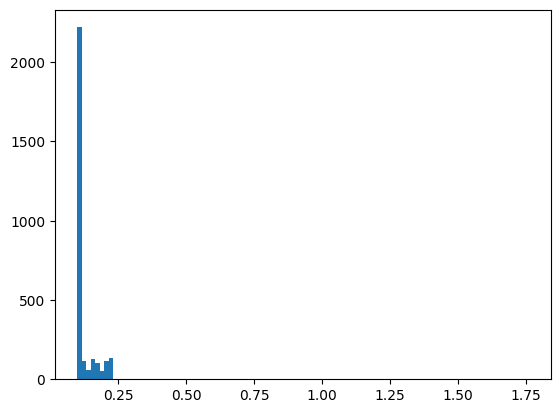

In [4]:
plt.figure()
plt.hist(train_rows[train_rows['severity'] == 1]['haptoglobin'],bins=100)
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve
import joblib

antitrypsin_normal = train_rows['antitrypsin'] / 1.5
oros_normal = train_rows['orosomukoid'] / 0.77
hapto_normal = train_rows['haptoglobin'] / 1.6

anti_minus_oro = antitrypsin_normal - oros_normal
anti_minus_hapto = antitrypsin_normal - hapto_normal
oros_minus_hapto = oros_normal - hapto_normal

leverprofil = ((anti_minus_oro > 0.05) & (anti_minus_hapto > 0.2) & (oros_minus_hapto > 0)).astype(int)
print(sum(leverprofil)/len(train_rows))


0.12800719118393786



X_test = np.vstack(test_rows[protein_cols].to_numpy())
X_test = X_test[:,0:5]

predictions = model.predict(X_test)
print(classification_report(y_test, predictions, target_names=['Negativ', 'Positiv']))

print(confusion_matrix(y_test, predictions))

probs = model.predict_proba(X_test)[:, 1]


print(model.coef_)
PROTEIN_LABELS = ['Albumin','Orosomukoid','Antitrypsin','Haptoglobin','CRP']
print(PROTEIN_LABELS)

## Resultat: 

Över 13 år: alla under 0,24 ska få kommentar 42